# 02 — Feature Engineering
## Projet : Home Credit Default Risk — MLOps Pipeline

**Objectif :** Nettoyer les données et créer de nouvelles variables pour améliorer les performances du modèle.

**Ce qu'on fait dans ce notebook :**
1. Supprimer les colonnes trop incomplètes
2. Corriger l'anomalie DAYS_EMPLOYED
3. Créer de nouvelles features
4. Remplir les valeurs manquantes restantes
5. Encoder les variables catégorielles
6. Sauvegarder les données propres

---

## 0. Imports et chargement des données

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Créer les dossiers si ils n'existent pas
os.makedirs('../data/processed', exist_ok=True)

# Couleurs du projet
COLOR_POS = '#E07B4F'
COLOR_NEG = '#2C5F8A'

# Chargement
df = pd.read_csv(r'C:\Users\Frank\Desktop\home-credit-MLOPS\data\raw\application_train.csv', low_memory=False)

print(f'✅ Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'   Dont TARGET : {df["TARGET"].value_counts().to_dict()}')

✅ Dataset chargé : 307,511 lignes × 122 colonnes
   Dont TARGET : {0: 282686, 1: 24825}


---
## Étape 1 — Supprimer les colonnes trop incomplètes

**Pourquoi ?**  
Une colonne avec 70% de valeurs manquantes n'apporte presque aucune information au modèle.  
Elle risque même de le perturber. On fixe un seuil à **60%** : toute colonne avec plus de 60% de NaN est supprimée.

**Exemple concret :**  
Imagine une colonne `FONDAPRICE_AVG` où 70% des clients n'ont pas de valeur.  
Le modèle ne peut pas apprendre grand chose avec seulement 30% de données réelles.

In [3]:
# Calculer le % de valeurs manquantes pour chaque colonne
pct_missing = df.isnull().mean() * 100

# Identifier les colonnes à supprimer (seuil = 60%)
SEUIL = 60
cols_a_supprimer = pct_missing[pct_missing > SEUIL].index.tolist()

print(f'Colonnes avec plus de {SEUIL}% de valeurs manquantes : {len(cols_a_supprimer)}')
print(f'\nListe de ces colonnes :')
for col in cols_a_supprimer:
    print(f'  {col} : {pct_missing[col]:.1f}% manquant')

# Supprimer ces colonnes
df = df.drop(columns=cols_a_supprimer)

print(f'\n✅ Dataset après suppression : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'   (on est passé de 122 à {df.shape[1]} colonnes)')

Colonnes avec plus de 60% de valeurs manquantes : 17

Liste de ces colonnes :
  OWN_CAR_AGE : 66.0% manquant
  YEARS_BUILD_AVG : 66.5% manquant
  COMMONAREA_AVG : 69.9% manquant
  FLOORSMIN_AVG : 67.8% manquant
  LIVINGAPARTMENTS_AVG : 68.4% manquant
  NONLIVINGAPARTMENTS_AVG : 69.4% manquant
  YEARS_BUILD_MODE : 66.5% manquant
  COMMONAREA_MODE : 69.9% manquant
  FLOORSMIN_MODE : 67.8% manquant
  LIVINGAPARTMENTS_MODE : 68.4% manquant
  NONLIVINGAPARTMENTS_MODE : 69.4% manquant
  YEARS_BUILD_MEDI : 66.5% manquant
  COMMONAREA_MEDI : 69.9% manquant
  FLOORSMIN_MEDI : 67.8% manquant
  LIVINGAPARTMENTS_MEDI : 68.4% manquant
  NONLIVINGAPARTMENTS_MEDI : 69.4% manquant
  FONDKAPREMONT_MODE : 68.4% manquant

✅ Dataset après suppression : 307,511 lignes × 105 colonnes
   (on est passé de 122 à 105 colonnes)


---
## Étape 2 — Corriger l'anomalie DAYS_EMPLOYED

**Rappel de l'EDA :**  
55 374 clients ont `DAYS_EMPLOYED = 365243`. C'est une valeur impossible (≈ 1000 ans).  
C'est un **code spécial** utilisé pour les clients sans emploi (retraités, chômeurs, etc.).

**Ce qu'on va faire :**
- Créer une nouvelle colonne `DAYS_EMPLOYED_ANOM` = 1 si le client a cette valeur anormale, 0 sinon
- Remplacer 365243 par NaN (on le remplira après avec la médiane)

**Pourquoi créer un flag ?**  
Parce que le fait d'être sans emploi est une **information utile** pour le modèle.  
Si on remplace juste par NaN sans garder cette info, on la perd.

In [4]:
# Créer le flag : 1 = anomalie détectée, 0 = valeur normale
df['DAYS_EMPLOYED_ANOM'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)

# Remplacer la valeur anormale par NaN
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

print('✅ Anomalie DAYS_EMPLOYED corrigée')
print(f'   Clients avec flag = 1 (sans emploi) : {df["DAYS_EMPLOYED_ANOM"].sum():,}')
print(f'   Clients avec flag = 0 (emploi normal) : {(df["DAYS_EMPLOYED_ANOM"]==0).sum():,}')
print(f'\n   Vérification — NaN dans DAYS_EMPLOYED : {df["DAYS_EMPLOYED"].isnull().sum():,}')

✅ Anomalie DAYS_EMPLOYED corrigée
   Clients avec flag = 1 (sans emploi) : 55,374
   Clients avec flag = 0 (emploi normal) : 252,137

   Vérification — NaN dans DAYS_EMPLOYED : 55,374


---
## Étape 3 — Créer de nouvelles features

**Pourquoi créer de nouvelles features ?**  
Les colonnes brutes du dataset ne capturent pas toujours bien la réalité.  
En combinant des colonnes existantes, on peut créer des variables plus informatives.

**Exemple :**  
Un revenu de 100 000 FCFA c'est bien ou pas ? Ça dépend du crédit demandé.  
Si le crédit est de 500 000 FCFA → ratio = 5 → risqué.  
Si le crédit est de 50 000 FCFA → ratio = 0.5 → raisonnable.  
Le **ratio** est plus informatif que les deux valeurs séparées.

In [5]:
# ── Feature 1 : Âge en années ─────────────────────────────────────────────────
# DAYS_BIRTH est négatif → on le rend positif et on divise par 365.25
df['AGE_YEARS'] = -df['DAYS_BIRTH'] / 365.25
print(f'AGE_YEARS — min: {df["AGE_YEARS"].min():.1f} | max: {df["AGE_YEARS"].max():.1f} | moy: {df["AGE_YEARS"].mean():.1f}')

# ── Feature 2 : Ancienneté emploi en années ───────────────────────────────────
# Même logique que AGE_YEARS
df['YEARS_EMPLOYED'] = -df['DAYS_EMPLOYED'] / 365.25
print(f'YEARS_EMPLOYED — moy: {df["YEARS_EMPLOYED"].mean():.1f} ans (NaN pour les sans-emploi)')

# ── Feature 3 : Ratio crédit / revenu ────────────────────────────────────────
# Plus ce ratio est élevé, plus le client emprunte par rapport à ce qu'il gagne
df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
print(f'CREDIT_INCOME_RATIO — moy: {df["CREDIT_INCOME_RATIO"].mean():.2f}')

# ── Feature 4 : Ratio annuité / revenu ───────────────────────────────────────
# Part du revenu consacrée au remboursement mensuel
# Si ce ratio est élevé → le client a du mal à rembourser
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
print(f'ANNUITY_INCOME_RATIO — moy: {df["ANNUITY_INCOME_RATIO"].mean():.4f}')

# ── Feature 5 : Ratio crédit / prix du bien ───────────────────────────────────
# Si le crédit est beaucoup plus élevé que le prix du bien → suspect
df['CREDIT_GOODS_RATIO'] = df['AMT_CREDIT'] / df['AMT_GOODS_PRICE']
print(f'CREDIT_GOODS_RATIO — moy: {df["CREDIT_GOODS_RATIO"].mean():.4f}')

# ── Feature 6 : Moyenne des scores externes ───────────────────────────────────
# EXT_SOURCE_1, 2, 3 sont les features les plus prédictives (vues en EDA)
# On crée leur moyenne pour avoir un seul score synthétique
ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
ext_available = [c for c in ext_cols if c in df.columns]
df['EXT_SOURCE_MEAN'] = df[ext_available].mean(axis=1)
print(f'EXT_SOURCE_MEAN — moy: {df["EXT_SOURCE_MEAN"].mean():.4f} | NaN: {df["EXT_SOURCE_MEAN"].isnull().sum():,}')

# ── Feature 7 : Nombre d'années depuis l'enregistrement ──────────────────────
df['YEARS_REGISTRATION'] = -df['DAYS_REGISTRATION'] / 365.25

print('\n✅ 7 nouvelles features créées')

AGE_YEARS — min: 20.5 | max: 69.1 | moy: 43.9
YEARS_EMPLOYED — moy: 6.5 ans (NaN pour les sans-emploi)
CREDIT_INCOME_RATIO — moy: 3.96
ANNUITY_INCOME_RATIO — moy: 0.1809
CREDIT_GOODS_RATIO — moy: 1.1230
EXT_SOURCE_MEAN — moy: 0.5093 | NaN: 172

✅ 7 nouvelles features créées


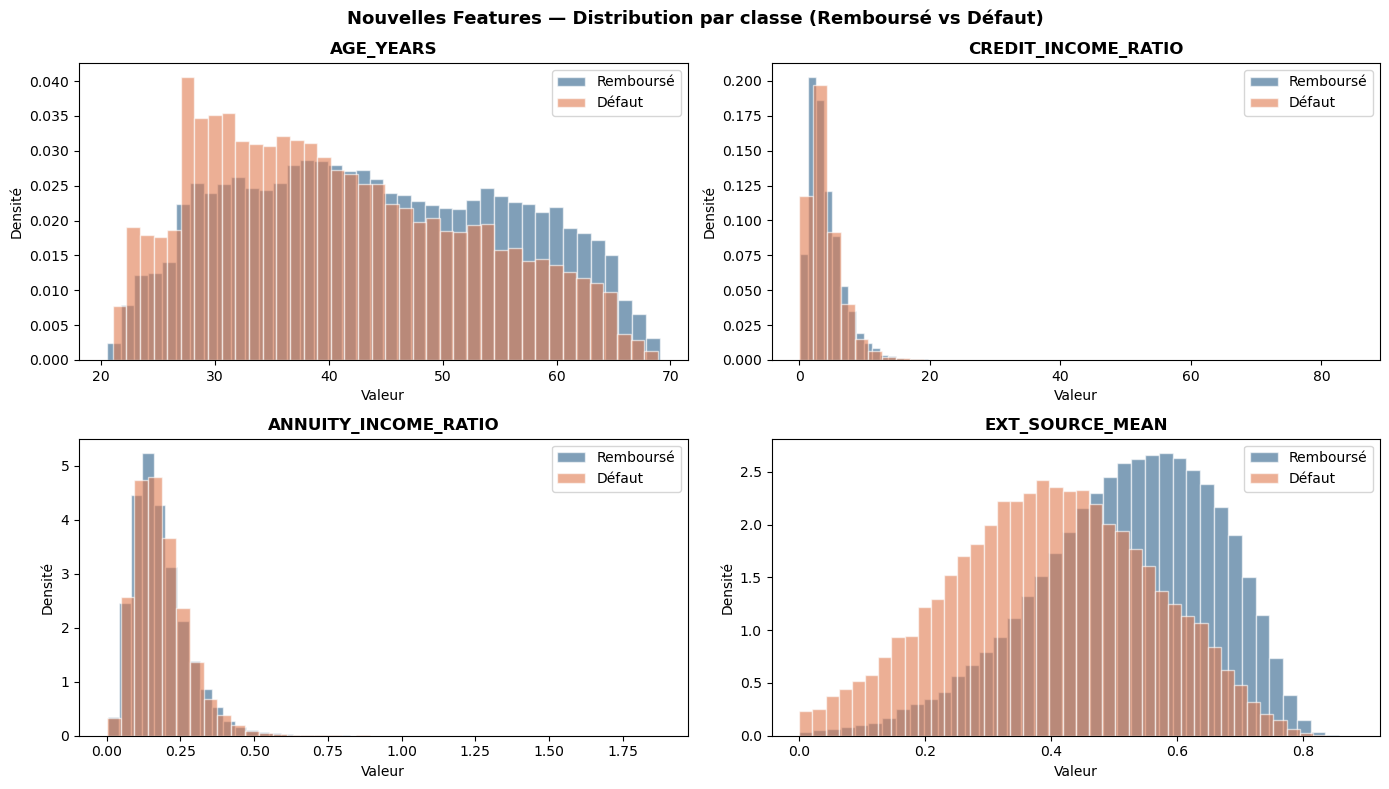


Corrélation des nouvelles features avec TARGET :
  AGE_YEARS                      : -0.0782
  YEARS_EMPLOYED                 : -0.0750
  CREDIT_INCOME_RATIO            : -0.0077
  ANNUITY_INCOME_RATIO           : +0.0143
  CREDIT_GOODS_RATIO             : +0.0694
  EXT_SOURCE_MEAN                : -0.2221


In [6]:
# ── Visualisation : les nouvelles features vs TARGET ──────────────────────────
new_features = ['AGE_YEARS', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'EXT_SOURCE_MEAN']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(new_features):
    for target, color, label in [(0, COLOR_NEG, 'Remboursé'), (1, COLOR_POS, 'Défaut')]:
        subset = df[df['TARGET'] == target][col].dropna()
        axes[i].hist(subset, bins=40, color=color, alpha=0.6,
                     label=f'{label}', edgecolor='white', density=True)
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_xlabel('Valeur')
    axes[i].set_ylabel('Densité')
    axes[i].legend()

plt.suptitle('Nouvelles Features — Distribution par classe (Remboursé vs Défaut)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_new_features.png', bbox_inches='tight', dpi=150)
plt.show()

# Corrélation des nouvelles features avec TARGET
print('\nCorrélation des nouvelles features avec TARGET :')
new_num_cols = ['AGE_YEARS', 'YEARS_EMPLOYED', 'CREDIT_INCOME_RATIO',
                'ANNUITY_INCOME_RATIO', 'CREDIT_GOODS_RATIO', 'EXT_SOURCE_MEAN']
for col in new_num_cols:
    corr = df[col].corr(df['TARGET'])
    print(f'  {col:30s} : {corr:+.4f}')

---
## Étape 4 — Remplir les valeurs manquantes (Imputation)

**Pourquoi on ne peut pas laisser des NaN ?**  
La plupart des algorithmes ML (Random Forest, XGBoost...) ne savent pas gérer les NaN.  
Il faut les remplacer par une valeur.

**Stratégie :**
- **Colonnes numériques** → on remplace par la **médiane**  
  (on utilise la médiane plutôt que la moyenne car elle est moins sensible aux valeurs extrêmes)
- **Colonnes catégorielles** → on remplace par la **valeur la plus fréquente** (le mode)

In [7]:
# Séparer colonnes numériques et catégorielles
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# Retirer TARGET des colonnes numériques (on ne touche pas à la cible)
num_cols = [c for c in num_cols if c != 'TARGET']

print(f'Colonnes numériques à imputer : {len(num_cols)}')
print(f'Colonnes catégorielles à imputer : {len(cat_cols)}')

# ── Imputation numérique : médiane ────────────────────────────────────────────
for col in num_cols:
    if df[col].isnull().sum() > 0:
        mediane = df[col].median()
        df[col] = df[col].fillna(mediane)

# ── Imputation catégorielle : mode (valeur la plus fréquente) ─────────────────
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        mode = df[col].mode()[0]  # [0] car mode() retourne une liste
        df[col] = df[col].fillna(mode)

# Vérification
total_nan = df.isnull().sum().sum()
print(f'\n✅ Imputation terminée')
print(f'   Valeurs manquantes restantes : {total_nan}')
if total_nan == 0:
    print('   → Plus aucun NaN dans le dataset ✅')

Colonnes numériques à imputer : 97
Colonnes catégorielles à imputer : 15

✅ Imputation terminée
   Valeurs manquantes restantes : 0
   → Plus aucun NaN dans le dataset ✅


---
## Étape 5 — Encoder les variables catégorielles

**Pourquoi encoder ?**  
Un modèle ML travaille uniquement avec des **nombres**.  
Il ne comprend pas les textes comme `'Male'`, `'Female'`, `'Cash loans'`.

**Technique utilisée : One-Hot Encoding**  
On transforme chaque catégorie en une colonne de 0 et 1.

Exemple :
```
CODE_GENDER = 'M'   →   CODE_GENDER_M = 1, CODE_GENDER_F = 0
CODE_GENDER = 'F'   →   CODE_GENDER_M = 0, CODE_GENDER_F = 1
```

`pd.get_dummies()` fait ça automatiquement pour toutes les colonnes catégorielles.

In [8]:
print(f'Colonnes catégorielles à encoder : {cat_cols}')
print(f'\nNombre de colonnes AVANT encodage : {df.shape[1]}')

# One-Hot Encoding
# drop_first=True évite la multicolinéarité
# (si on a M et F, on n'a besoin que d'une colonne : 1=M, 0=F)
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(f'Nombre de colonnes APRÈS encodage : {df.shape[1]}')
print(f'\n✅ Encodage terminé')
print(f'   Nouvelles colonnes créées : {df.shape[1] - len(num_cols) - 1}')

# Aperçu des nouvelles colonnes créées
new_dummy_cols = [c for c in df.columns if '_' in c and c not in num_cols and c != 'TARGET']
print(f'\nExemples de colonnes encodées :')
for col in new_dummy_cols[:10]:
    print(f'  {col}')

Colonnes catégorielles à encoder : ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']

Nombre de colonnes AVANT encodage : 113
Nombre de colonnes APRÈS encodage : 219

✅ Encodage terminé
   Nouvelles colonnes créées : 121

Exemples de colonnes encodées :
  NAME_CONTRACT_TYPE_Revolving loans
  CODE_GENDER_M
  CODE_GENDER_XNA
  FLAG_OWN_CAR_Y
  FLAG_OWN_REALTY_Y
  NAME_TYPE_SUITE_Family
  NAME_TYPE_SUITE_Group of people
  NAME_TYPE_SUITE_Other_A
  NAME_TYPE_SUITE_Other_B
  NAME_TYPE_SUITE_Spouse, partner


---
## Étape 6 — Vérification finale et sauvegarde

On vérifie que tout est propre, puis on sauvegarde le dataset nettoyé.  
Ce fichier sera utilisé dans le notebook `03_Modeling.ipynb`.

In [9]:
# ── Vérification finale ────────────────────────────────────────────────────────
print('=' * 60)
print('VÉRIFICATION FINALE DU DATASET NETTOYÉ')
print('=' * 60)
print(f'Dimensions      : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'Valeurs NaN     : {df.isnull().sum().sum()}')
print(f'Types de données:')
print(df.dtypes.value_counts().to_string())
print(f'\nDistribution TARGET :')
print(df['TARGET'].value_counts().to_string())
print('=' * 60)

VÉRIFICATION FINALE DU DATASET NETTOYÉ
Dimensions      : 307,511 lignes × 219 colonnes
Valeurs NaN     : 0
Types de données:
bool       121
float64     57
int64       41

Distribution TARGET :
TARGET
0    282686
1     24825


In [11]:
# ── Sauvegarde ────────────────────────────────────────────────────────────────
OUTPUT_PATH = '../data/processed/application_train_clean.csv'
df.to_csv(OUTPUT_PATH, index=False)

print(f'✅ Dataset propre sauvegardé : {OUTPUT_PATH}')
print(f'   Taille du fichier : {os.path.getsize(OUTPUT_PATH)/1e6:.1f} MB')
print(f'\n🎯 Prochaine étape : 03_Modeling.ipynb')
print('   → On va entraîner plusieurs modèles et les comparer avec MLflow')

✅ Dataset propre sauvegardé : ../data/processed/application_train_clean.csv
   Taille du fichier : 391.6 MB

🎯 Prochaine étape : 03_Modeling.ipynb
   → On va entraîner plusieurs modèles et les comparer avec MLflow


---
## Récapitulatif — Ce qu'on a fait dans ce notebook

| Étape | Action | Résultat |
|---|---|---|
| 1 | Suppression colonnes > 60% NaN | De 122 → colonnes restantes |
| 2 | Correction DAYS_EMPLOYED | Flag créé + NaN remplacé |
| 3 | Création nouvelles features | 7 nouvelles variables |
| 4 | Imputation des NaN | 0 valeurs manquantes |
| 5 | One-Hot Encoding | Catégorielles → numériques |
| 6 | Sauvegarde | application_train_clean.csv |

**Le dataset est maintenant prêt pour la modélisation.**